# 单元六作业
    刘易昊 524021910055

## 背景与研究问题

研究问题：
1. 年龄（age_years）与收缩压（sbp_mmHg）之间是否存在线性相关？（Pearson r）
2. 疼痛评分（pain_score_VAS）与功能障碍指数（disability_index）之间是否存在单调相关？（Spearman ρ 与 Kendall τ）
3. Spearman ρ 与 Kendall τ 描述同⼀对变量的相关程度是否有显著差异？（挑战题）

## 任务 1：散点图（0.4 分） 
对变量对 A 和变量对 B 分别绘制散点图。要求：
- 坐标轴标注变量名称和单位
- 添加趋势线（可选线性回归线）
- 给出图题（Figure 1, Figure 2）
- 简要描述图中展示的关联趋势（⽅向、强度的主观判断）


In [1]:
#加载头文件
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
pd.set_option("display.precision", 3)

#中文显示设置
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]  

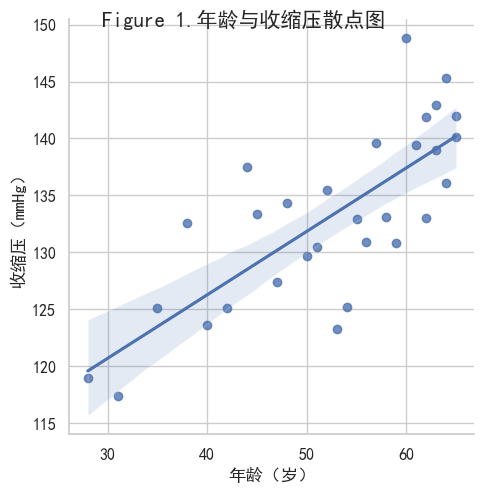

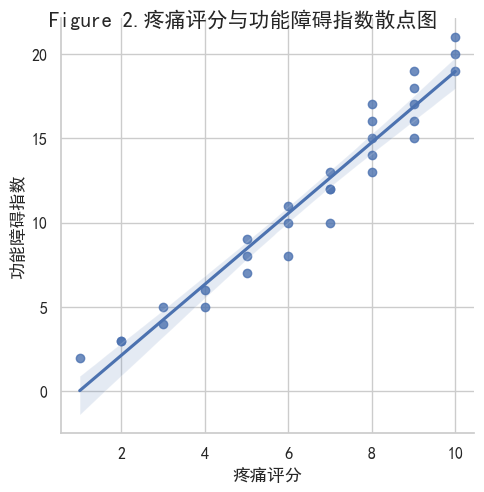

In [2]:
data=pd.read_csv("BME2202_HW6_data.csv") 

f1 = sns.lmplot(x="age_years", y="sbp_mmHg", data=data, height=5)
f1.set_axis_labels("年龄（岁）", "收缩压（mmHg）")
f1.figure.suptitle("Figure 1.年龄与收缩压散点图")


f2 = sns.lmplot(x="pain_score_VAS", y="disability_index", data=data, height=5)
f2.set_axis_labels("疼痛评分", "功能障碍指数")
f2.figure.suptitle("Figure 2.疼痛评分与功能障碍指数散点图")

plt.show()

可以看到，收缩压关于年龄正相关，功能障碍指数也关于疼痛评分正相关。而在相关强度上，两者都较强，但图二的相关性强度显著大于图一。

## 任务 2：适⽤条件评估（0.4 分） 
针对变量对 A（年龄 vs. 收缩压），逐条评估以下 Pearson r 的适⽤条件：

1. 两变量是否为连续变量（或近似连续）？
2. 每⾏观测是否独⽴的配对 (x, y)？
3. 散点图是否显示近似线性关系？
4. 是否存在⾼杠杆异常值？
5. 两变量的边际分布是否近似正态（可通过直⽅图或 Q-Q 图辅助判断）？

针对变量对 B（疼痛评分 vs. 功能障碍指数），说明为何选⽤⾮参数相关系数（Spearman ρ 和 Kendall τ）⽽不是 Pearson r。

### 对于变量对A：
1. 两个变量是连续变量或近似连续变量。年龄虽然是离散型数值变量，只能为正整数，但是由于年龄跨度较大且具有实际的物理意义，表示时间的尺度，所以可以近似连续变量；而收缩压本身就是连续型的数值变量。
2. 每次观测确是独立配对的数据组。对于一个病人，他的年龄和收缩压在观测时自动配对，并且相互独立。
3. 由Figure 1可以看到，两者是有近似的正相关线性关系。
4. 从Figure 1中观察，并不存在高杠杆的异常值
5. 绘图分析如下：

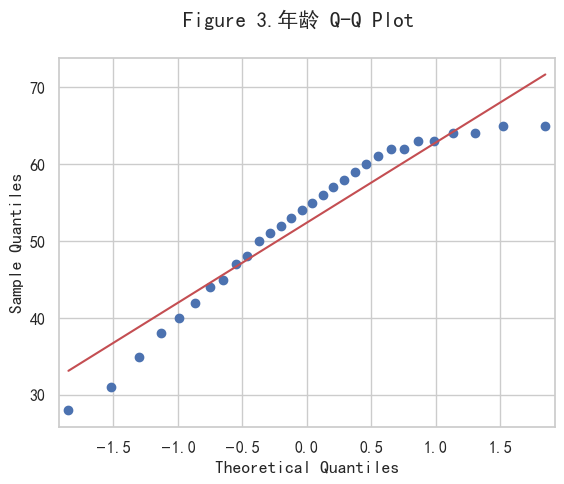

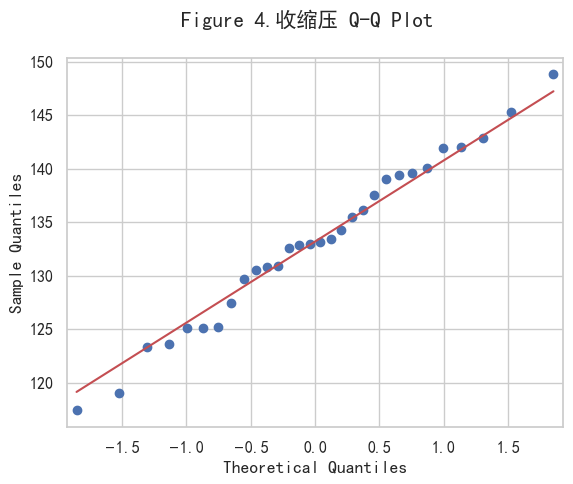

In [3]:
import statsmodels.api as sm

f3 = sm.qqplot(data["age_years"], stats.norm,line='s')
f3.figure.suptitle("Figure 3.年龄 Q-Q Plot")
f4 = sm.qqplot(data["sbp_mmHg"], stats.norm,line='s')
f4.figure.suptitle("Figure 4.收缩压 Q-Q Plot")
plt.show() 

如上图，从 Q-Q Plot 可以判断，年龄和收缩压两个变量的边际分布是近似正态分布的。

### 对于变量对B：
疼痛评分取值在[0, 10]，取值为整数，且具有显著的等级顺序；功能障碍指数同样也是取值为整数的离散型变量，且在本研究中取值为[3, 21]，也具有显著的等级顺序。变量对并不符合pearson $r$的前提条件，并且更适合定序变量的计算方法Spearman $\rho$ 和 Kendall $\tau$。

## 任务 3：计算样本相关系数（0.3分） 
使⽤ Python（scipy.stats）分别计算：
- 变量对 A：Pearson 相关系数  及其对应 p 值
- 变量对 B：Spearman 相关系数  及其对应 p 值
- 变量对 B：Kendall 相关系数  及其对应 p 值

并⽤表格汇总三个相关系数、样本量 、⾃由度 df（如适⽤）。


In [4]:
summary = pd.DataFrame(
    [
        {
            "变量对":"A",
            "method": "Pearson r",
            "相关系数": stats.pearsonr(data["age_years"], data["sbp_mmHg"]).statistic,
            "p": stats.pearsonr(data["age_years"], data["sbp_mmHg"]).pvalue,
            "样本量":len(data),
            "df":len(data)-2
        },
        {
            "变量对":"B",
            "method": "Spearman rho",
            "相关系数": stats.spearmanr(data["pain_score_VAS"], data["disability_index"]).statistic,
            "p": stats.spearmanr(data["pain_score_VAS"], data["disability_index"]).pvalue,
            "样本量":len(data),
            "df":"不适用"
        },
        {
            "变量对":"B",
            "method": "Kendall tau",
            "相关系数": stats.kendalltau(data["pain_score_VAS"], data["disability_index"]).statistic,
            "p": stats.kendalltau(data["pain_score_VAS"], data["disability_index"]).pvalue,
            "样本量":len(data),
            "df":"不适用"
        },
    ]
)
display(summary)

,变量对,method,相关系数,p,样本量,df
0,A,Pearson r,0.763,9.248e-07,30,28
1,B,Spearman rho,0.977,2.432e-20,30,不适用
2,B,Kendall tau,0.923,8.319e-12,30,不适用


## 任务 4：推断置信区间（0.3分） 
计算以下三个相关系数的 95% 置信区间：
- Pearson r 的置信区间（Fisher Z 变换法或Bootstrap）
- Spearman ρ 的置信区间（Fisher Z 变换法或Bootstrap）
- Kendall τ 的置信区间（Fisher Z 变换法或Bootstrap）

请报告每个系数的点估计和 95% CI [下界, 上界]。

In [5]:
pearson = stats.pearsonr(data["age_years"], data["sbp_mmHg"])
pearson_ci = pearson.confidence_interval(confidence_level=0.95)
print("Pearson r的95%置信区间 : [{:.3f}, {:.3f}]".format(pearson_ci.low, pearson_ci.high))

Pearson r的95%置信区间 : [0.556, 0.881]


这里均采用Fishe z变换来计算spearman和kendall两种情况下的置信区间，先进行函数定义再代入参数进行计算：

In [6]:
def fisher_z_ci_spearman(r, n):
    z=np.arctanh(r)
    se=np.sqrt((1+0.5*r**2)/(n-3)) 
    z_crit = stats.norm.ppf((1 + 0.95)/2)  
    ci_lower_z = z - z_crit * se
    ci_upper_z = z + z_crit * se
    ci_lower = np.tanh(ci_lower_z)
    ci_upper = np.tanh(ci_upper_z)
    return round(ci_lower,4), round(ci_upper,4)
    
rho = stats.spearmanr(data["pain_score_VAS"], data["disability_index"]).statistic
n = len(data)
l,h = fisher_z_ci_spearman(rho, n)

print("Spearman rho的95%置信区间 : [{:.3f}, {:.3f}]".format(l, h))

Spearman rho的95%置信区间 : [0.944, 0.991]


In [7]:
def fisher_z_ci_kendall(r, n):
    z=np.arctanh(r)
    se=np.sqrt(0.437/(n-4))
    z_crit = stats.norm.ppf((1 + 0.95)/2)  
    ci_lower_z = z - z_crit * se
    ci_upper_z = z + z_crit * se
    ci_lower = np.tanh(ci_lower_z)
    ci_upper = np.tanh(ci_upper_z)
    return round(ci_lower,4), round(ci_upper,4)
    
tau = stats.kendalltau(data["pain_score_VAS"], data["disability_index"]).statistic
n = len(data)
l,h = fisher_z_ci_kendall(tau, n)

print("Kendall's tau的95%置信区间 : [{:.3f}, {:.3f}]".format(l, h))

Kendall's tau的95%置信区间 : [0.875, 0.953]


在附加任务中我也采取了Bootstrap方法来计算rho和tau的置信区间，结果如下：
- Spearman rho的95%CI: [0.934, 0.991]
- Kendall tau的95%CI: [0.860, 0.963]

## 任务 5：显著性检验（0.3分，每个系数0.1分） 
对上述三个相关系数，分别进⾏双侧显著性检验。完整的四步骤如下：
- Step 1：提出假设
- Step 2：确定检验⽔准
- Step 3：计算检验统计量
- Step 4：得出结论

### 1.Pearson r
$H_0: r=0$，$H_1: r \neq 0$

设定显著性水平： $\alpha=0.05$

构造统计量： $t=\frac{r\cdot\sqrt{n-2}}{\sqrt{1-r^2}} \sim t_{n-2}$

计算p值：$p=p(|t_{n-2}| >t_{obs})$

In [8]:
pearson_p=stats.pearsonr(data["age_years"],data["sbp_mmHg"]).pvalue
print("pearson r的p值为：", pearson_p)

pearson r的p值为： 9.248402552885485e-07


$p=9.25\times 10^{-7} <.05$，拒绝 $H_0$，认为$r$不等于零。

### 2.Spearman rho
$H_0: \rho=0$，$H_1: \rho \neq 0$

设定显著性水平： $\alpha=0.05$

计算p值：

In [9]:
spearman_p=stats.spearmanr(data["pain_score_VAS"], data["disability_index"]).pvalue
print("spearman rho的p值为：", spearman_p)

spearman rho的p值为： 2.4321801116180323e-20


$p=2.43\times 10^{-20} <.05$，拒绝 $H_0$，认为$\rho$不等于零。

### 3.Kendall's tau
$H_0: \tau=0$，$H_1: \tau \neq 0$

设定显著性水平： $\alpha=0.05$

计算p值：

In [10]:
kendall_p=stats.kendalltau(data["pain_score_VAS"], data["disability_index"]).pvalue
print("kendall tau的p值为：", kendall_p)

kendall tau的p值为： 8.318898704479814e-12


$p=8.32\times 10^{-12} <.05$，拒绝 $H_0$，认为$\tau$不等于零。

## 任务 6：规范汇报（0.3分） 
按照课程推荐模板，对三个相关系数分别撰写规范的结果陈述句：
> 格式：[变量1] 与 [变量2] 的 [⽅法] 相关分析显示，两者呈 [⽅向/强度] 相关，统计量= [值], p [符号] [值], 95% CI [下界, 上界]。

要求：
- 不得仅写"p < 0.05，显著相关"
- 不得将相关关系解读为因果关系
- ⾄少⽤⼀句话说明该 CI 的实际含义

1. 年龄与收缩压的pearson r相关分析显示，两者呈正线性强相关，$r(df=28)=0.763$，$p=9.25 \times 10^{-7}$，95%CI [0.556, 0.881]。在当前样本和模型条件下，我们有证据支持总体存在线性相关，其中置信区间整体大于0.5，说明两个的线性正相关性很强。

2. 疼痛评分与功能障碍指数的spearman rho相关分析显示，两者呈正强相关，$\rho=0.977$，$p=2.43 \times 10^{-20}$，95%CI [0.944, 0.991]。在当前样本和模型条件下，我们有证据支持总体存在相关性，其中置信区间整体大于0.5，说明两个的正相关性很强。

3. 疼痛评分与功能障碍指数的kendall's tau相关分析显示，两者呈正强相关，$\tau=0.923$，$p=8.32 \times 10^{-12}$，95%CI [0.875, 0.953]。在当前样本和模型条件下，我们有证据支持总体存在相关性，其中置信区间整体大于0.5，说明两个的正相关性很强。

## 挑战题（课程附加分 0.5 分） 

**⽐较 Spearman ρ 与 Kendall τ 的差异是否显著**

对同⼀组数据（疼痛评分 vs. 功能障碍指数），你计算了 Spearman ρ 和 Kendall τ 两个相关系数。这两个系数描述的是同⼀对变量的单调相关，但它们的数值不同。

请使⽤以下⽅法推断⼆者的差异：
1. 基于各⾃的 Bootstrap CI，说明两个 CI 是否重叠，给出初步判断。
2. 使⽤ Bootstrap 差值检验（对每个 Bootstrap 样本同时计算 ρ 和 τ，得到 ρ − τ 的 Bootstrap 分布），计算差值 ρ − τ 的 95% CI。
3. 若差值 CI 不包含 0，则可认为⼆者在该样本中存在统计上显著的差异。
4. ⽤ 1–2 句话讨论：ρ 和 τ 的系统性差异在实际研究中有何意义？

In [11]:
#设定随机种子为我的学号后七位
np.random.seed(1910055) 

x = data["pain_score_VAS"]
y = data["disability_index"]
n = len(data)
n_boot = 10000

#分别计算两个CI

rho_list = []
tau_list = []

for _ in range(n_boot):
    idx = np.random.choice(n, size=n, replace=True)
    x_boot = x.iloc[idx]
    y_boot = y.iloc[idx]
    rho_list.append(stats.spearmanr(x_boot, y_boot)[0])
    tau_list.append(stats.kendalltau(x_boot, y_boot)[0])

rho_ci = np.percentile(rho_list, [2.5, 97.5])
tau_ci = np.percentile(tau_list, [2.5, 97.5])
print(f"Spearman rho的95%CI: [{rho_ci[0]:.3f}, {rho_ci[1]:.3f}]")
print(f"Kendall tau的95%CI: [{tau_ci[0]:.3f}, {tau_ci[1]:.3f}]")

#计算差值的CI

diff_list = []

for _ in range(n_boot):
    idx = np.random.choice(n, size=n, replace=True)
    x_boot = x.iloc[idx]
    y_boot = y.iloc[idx]
    rho, _ = stats.spearmanr(x_boot, y_boot)
    tau, _ = stats.kendalltau(x_boot, y_boot)
    diff = rho - tau
    diff_list.append(diff)

diff_ci = np.percentile(diff_list, [2.5, 97.5])
print(f"rho-tau的95%置信区间: [{diff_ci[0]:.3f}, {diff_ci[1]:.3f}]")


Spearman rho的95%CI: [0.934, 0.991]
Kendall tau的95%CI: [0.860, 0.963]
rho-tau的95%置信区间: [0.027, 0.076]


1. 用Bootstrap方法计算出的rho和tau的95%置信区间与使用Fisher z变换计算的置信区间相比，无明显区别。rho和tau的Bootstrap CI有明显重叠。
2. rho-tau差值的95%置信区间为[0.027,0.076]。
3. 差值CI不包括0，说明两者在本样本中具有统计上的显著差异
4. rho和tau的差异体现在他们对定序变量关系衡量的侧重点不一样：rho关注的是等级秩序的吻合度，可以用来衡量单调性；而tau更关注数据对之间是否具有一致性大小关系。

## AI使用声明
*豆包（13.4.0）- 思考模式*

* **Query：** 

你可以告诉我bootstrap是怎么计算置信区间的吗，和Fisher z变换有什么区别？

* **Output：**

我用大白话 + 分步拆解给你讲清楚 Bootstrap 置信区间，并和你熟悉的 Fisher Z 做个对比。

你熟悉的Fisher Z 变换是「参数法」：

先假设相关系数的分布可以通过公式（Z 变换）近似成正态分布

然后用正态分布的临界值（比如 1.96）来算置信区间

而 **Bootstrap（自助法）** 是「非参数法」，核心思想一句话：

用你手里的这组数据，自己给自己做 “模拟实验”，反复抽样，直接估计统计量的波动范围，不用假设任何分布。

就像你手里有 30 个数据，相当于 30 张牌，Bootstrap 就是：

反复从这 30 张牌里「有放回」抽 30 张（允许重复抽到同一张牌），生成很多组 “模拟数据”

每组模拟数据里，都算一次你要的统计量（比如 ρ、τ，或者它们的差值）

最后把所有统计量的结果排序，取中间 95% 的范围，就是 95% 置信区间。

* **验证修改：**

我通过ai对话了解了bootstrap的具体流程，然后编写python程序模拟反复抽取的过程，最后把自己的代码发给ai进行debug
